In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots


# Loading files

In [3]:
filelist = "fits_ready/filelist_results.txt"

with open(filelist, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

In [4]:
bundles = {}

for name in names:
    bundles[name] = results_comp.load_line_bundle(
        name, name, MAPS_DIR, read_header=True
    )

In [6]:
bundles["LVM-30Dor-6563_subrot"]

{'bundle_name': 'LVM-30Dor-6563_subrot',
 'data': 'LVM-30Dor-6563_subrot',
 'obs':            RAdeg      DEdeg    V_mean       log_F   sigma        v_  \
 0      84.675284 -69.325388  2.125417   3613.9817  0.8184  270.6156   
 1      84.700557 -69.320232  1.527726   4010.3631  0.8574  270.0741   
 2      84.725729 -69.315073  2.898721   3670.0312  0.8742  271.5013   
 3      84.750977 -69.309910  2.432952   3612.9011  0.8278  271.0919   
 4      84.776213 -69.304744 -5.406306   5570.7056  0.8080  263.3091   
 ...          ...        ...       ...         ...     ...       ...   
 20741  85.187001 -69.143128 -9.446770  13851.0813  0.7567  260.7357   
 20742  85.213306 -69.147431 -7.723773   9117.1498  0.7882  262.4522   
 20743  85.239622 -69.151730 -6.102811   7462.5250  0.7807  264.0667   
 20744  85.265948 -69.156025 -6.626787   5566.1327  0.8066  263.5363   
 20745  85.292285 -69.160316 -6.147301   5081.3018  0.8132  264.0094   
 
             v_mod  
 0      268.490183  
 1      26

In [7]:
dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

In [8]:
dfs_obs["LVM-30Dor-6563_subrot"]

,RAdeg,DEdeg,V_mean,log_F,sigma,v_,v_mod
0,84.675284,-69.325388,2.125417,3613.9817,0.8184,270.6156,268.490183
1,84.700557,-69.320232,1.527726,4010.3631,0.8574,270.0741,268.546374
2,84.725729,-69.315073,2.898721,3670.0312,0.8742,271.5013,268.602579
3,84.750977,-69.309910,2.432952,3612.9011,0.8278,271.0919,268.658948
4,84.776213,-69.304744,-5.406306,5570.7056,0.8080,263.3091,268.715406
...,...,...,...,...,...,...,...
20741,85.187001,-69.143128,-9.446770,13851.0813,0.7567,260.7357,270.182470
20742,85.213306,-69.147431,-7.723773,9117.1498,0.7882,262.4522,270.175973
20743,85.239622,-69.151730,-6.102811,7462.5250,0.7807,264.0667,270.169511
20744,85.265948,-69.156025,-6.626787,5566.1327,0.8066,263.5363,270.163087


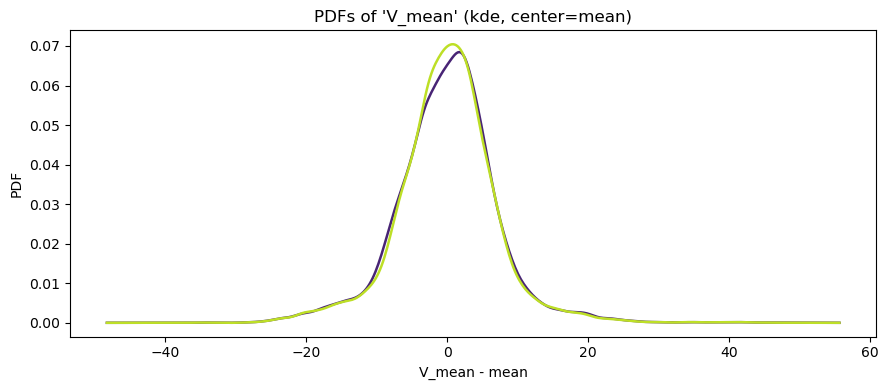

In [9]:
fig, ax, stats_df = list_maps_plots.plot_list_pdfs_circles(
    dfs_obs,
    col="V_mean",
    center="mean",
    method="kde",
    cmap="viridis",
    legend_mode="none",
    annotate=False,
    figsize=(9, 4),
    bw_scale=1.0
)

In [10]:
stats_df

,name,N,mean,std,var,xmin,xmax
0,LVM-30Dor-6563_subrot,20746,-3.130492,7.147537,51.087290,-43.539765,50.891223
1,LVM-30Dor-6563_rot,20746,266.929611,6.996529,48.951423,-43.390511,50.881889


In [11]:
dfs_fit['LVM-30Dor-6563_subrot']

,sig2,r0,m,s0,noise
0,56.542197,14.828806,1.347639,0.363610,0.794482
1,1.065150,0.942235,0.170786,-0.006574,2.849197
2,3.312678,0.606535,0.051541,0.328787,0.732893


In [21]:
labels = ['H_corr', 'H']

In [22]:
obs_var = [dfs_obs["LVM-30Dor-6563_subrot"]['V_mean'].var(), 
           dfs_obs["LVM-30Dor-6563_rot"]['V_mean'].var()
          ]
obs_var

[51.087289533200774, 48.95142287557257]

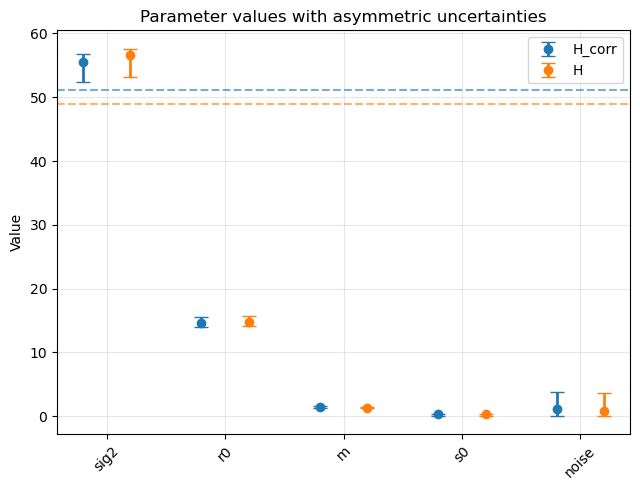

In [23]:
plot_fit_params.plot_param_comp_obs(dfs_fit['LVM-30Dor-6563_rot'],
                                    dfs_fit['LVM-30Dor-6563_subrot'], 
                                    labels=labels, obs=obs_var)

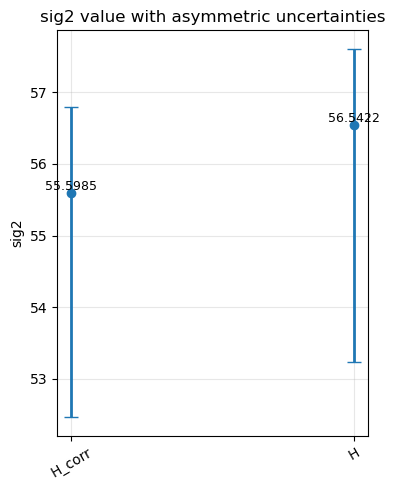

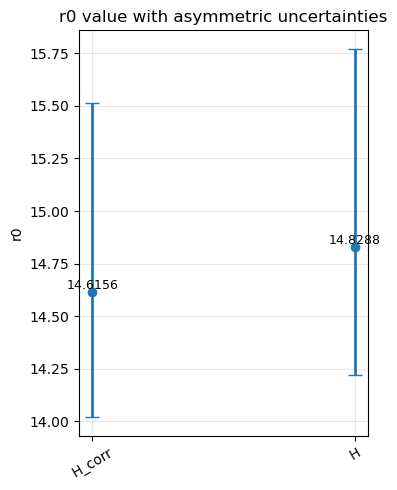

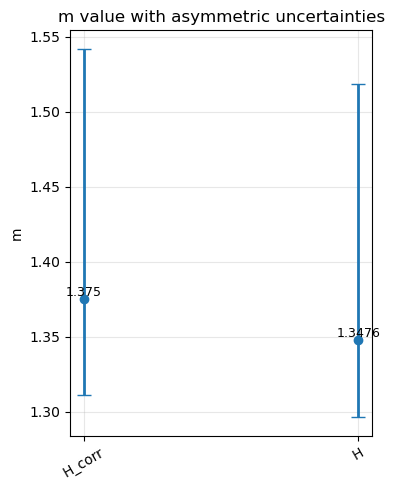

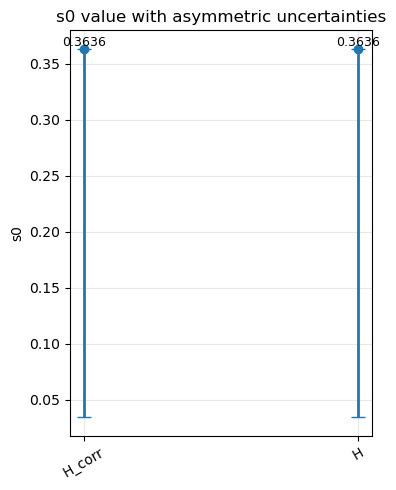

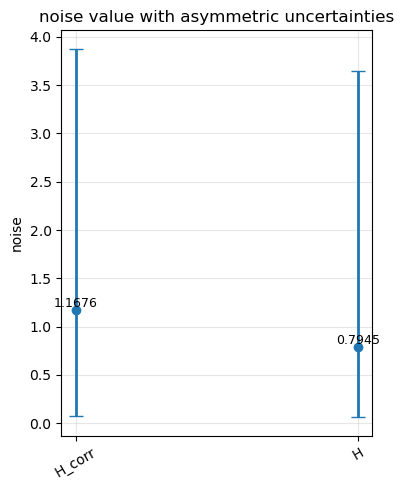

In [24]:
plot_fit_params.plot_param(dfs_fit['LVM-30Dor-6563_rot'],
                                    dfs_fit['LVM-30Dor-6563_subrot'], 
                                    labels=labels,
                                decimals=4)